In [1]:
import pandas as pd
import openml
import data_preprocess as dp

data_name = 'elevators'

data = openml.datasets.get_dataset(846)

X, y, categorical_indicator, attribute_names = data.get_data(
    target=data.default_target_attribute, dataset_format="dataframe"
)

/opt/anaconda3/envs/viashap_mac/lib/python3.10/site-packages/openml/datasets/functions.py:438: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(


# Data Preprocessing

In [2]:
from copy import deepcopy
import numpy as np

nominal = [b for a, b in zip(categorical_indicator, attribute_names) if a]
numerical = [b for a, b in zip(categorical_indicator, attribute_names) if not a]


encoded_data = deepcopy(X)

for col in nominal:
    
    mapping = {c: i+1 for i, c in enumerate(encoded_data[col].unique())}
    encoded_data[col] = encoded_data[col].replace(mapping)
    try:
        encoded_data[col] = encoded_data[col].cat.add_categories([0])
    except:
        continue

encoded_data = encoded_data[numerical + nominal]
encoded_data.fillna(0, inplace=True)

In [3]:
mapping = {b: i for i, b in enumerate(y.unique())}

y = y.replace(mapping)

/var/folders/z4/dpm1g__n41bdyk5z4bx31ypw0000gn/T/ipykernel_54123/311957160.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace(mapping)
/var/folders/z4/dpm1g__n41bdyk5z4bx31ypw0000gn/T/ipykernel_54123/311957160.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y = y.replace(mapping)


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split

train_data, left_out, train_label, y_left_out = train_test_split(encoded_data, y, test_size=0.3, 
                                                                 stratify=y, random_state=42)
test_data, dev_data, test_label, dev_label = train_test_split(left_out, y_left_out, test_size=0.5, 
                                                              stratify=y_left_out, random_state=42)


In [5]:
from sklearn.preprocessing import Normalizer, StandardScaler

ss = StandardScaler()

ss.fit(train_data[numerical])

train_data[numerical] = ss.transform(train_data[numerical])
dev_data[numerical] = ss.transform(dev_data[numerical])
test_data[numerical] = ss.transform(test_data[numerical])

In [6]:
index_to_name, name_to_index = dp.name_index(data=encoded_data)

In [7]:
from imblearn.over_sampling import RandomOverSampler

oversample = RandomOverSampler(sampling_strategy='minority')
X_over, y_over = oversample.fit_resample(train_data, train_label)

In [8]:
train = dp.transform_to_tensors(X_over, y_over, len(index_to_name))

test = dp.transform_to_tensors(test_data, test_label, len(index_to_name))

dev = dp.transform_to_tensors(dev_data, dev_label, len(index_to_name))


torch.Size([16056, 18])
torch.Size([16056])
torch.Size([2490, 18])
torch.Size([2490])
torch.Size([2490, 18])
torch.Size([2490])


In [9]:
from torch.utils.data import DataLoader
import torch

batch_size = 64

train_dataset = dp.Data(data=train)
val_dataset = dp.Data(data=dev)
test_dataset = dp.Data(data=test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

# Train KAN

In [10]:
import torch
import os.path
from kanshap import train_model, KANSHAP
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score
torch.manual_seed(5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if os.path.isfile(f'{data_name}/{data_name}_kan.model'):
    
    print('Loading saved model')
    kan_model = KANSHAP(len(index_to_name), 1, index_to_name, dataframe=encoded_data, 
            categorical=nominal, 
            numerical=numerical,link_function = None).to(device)
    kan_model.load_state_dict(torch.load(f'{data_name}/{data_name}_kan.model'))
    
else:
    kan_model = train_model(index_to_name=index_to_name,
                train_dataloader=train_dataloader,
                val_dataloader=val_dataloader,
                data_name=data_name,
                num_classes=1,
                dataframe=encoded_data, 
                categorical=nominal, 
                numerical=numerical,
                kan_model=None, 
                optimizer_train=None, 
                current_epoch=1,
                max_num_epochs=300,
                learning_rate=1e-03,
                num_samples=32,
                alpha=1, beta=10,
                patience=15)


100%|██████████| 39/39 [00:01<00:00, 25.42it/s]


Classification loss: 0.1816779226064682
interpretability loss: 0.008339072577655315
Acc at dev is : 0.714
ROC is : 0.745,  prec 0.7092490960743802,  recall 0.744879099987986, f-score 0.701903306948888
Acc at epoch : 1 is : 0.7133781909942627, loss : 66.93520832061768


100%|██████████| 39/39 [00:01<00:00, 25.61it/s]


Classification loss: 0.1606990396976471
interpretability loss: 0.009281613864004612
Acc at dev is : 0.774
ROC is : 0.781,  prec 0.7477599304579409,  recall 0.7806148933581876, f-score 0.7548085818573279
Acc at epoch : 2 is : 0.7668784260749817, loss : 46.125743106007576


100%|██████████| 39/39 [00:01<00:00, 26.10it/s]


...

Classification loss: 0.0947776809334755
interpretability loss: 0.022259747609496117
Acc at dev is : 0.876
ROC is : 0.852030,  prec 0.8551339641324175,  recall 0.8520298099889002, f-score 0.8535517541536357
Acc at epoch : 38 is : 0.9457523822784424, loss : 22.06902115046978
EarlyStopping counter: 13/15


100%|██████████| 39/39 [00:01<00:00, 21.69it/s]


Classification loss: 0.09181205183267593
interpretability loss: 0.02118135243654251
Acc at dev is : 0.883
ROC is : 0.855392,  prec 0.8672649500571579,  recall 0.8553918586964817, f-score 0.8609252266042235
Acc at epoch : 39 is : 0.9463129043579102, loss : 21.951895032078028
EarlyStopping counter: 14/15


100%|██████████| 39/39 [00:01<00:00, 22.01it/s]

Classification loss: 0.09288711100816727
interpretability loss: 0.021377060562372208
Acc at dev is : 0.883
ROC is : 0.856471,  prec 0.866607452582107,  recall 0.856470857584992, f-score 0.861242260836361
Acc at epoch : 40 is : 0.9469357132911682, loss : 21.86405397206545
EarlyStopping counter: 15/15
Early stopping at epoch 40
Best validation result is at epoch: 25


## Evaluate the trained model on the test set

In [11]:
from tqdm import tqdm


list_prediction = []
list_pob_pred = []
y_test = []
subsample_indices = np.random.choice(len(test_dataset), size=300, replace=False)
test_subset = [test_dataset[i] for i in subsample_indices]
for i, data in tqdm(list(enumerate(test_dataloader))):
    inputs, labels = data

    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = kan_model(inputs)
    list_pob_pred.extend(outputs.tolist())

    preds = (outputs.reshape(-1) > 0.5) * 1

    list_prediction.extend(preds.tolist())

    y_test.extend(labels.tolist())

    torch.cuda.empty_cache()


roc = roc_auc_score(y_test, list_pob_pred)
prec = precision_score(y_test, list_prediction, average='macro')
recall = recall_score(y_test, list_prediction, average='macro')
f_score = f1_score(y_test, list_prediction, average='macro')

print('AUC is : {},  prec {},  recall {}, f-score {}' .format(roc, prec, recall, f_score))

100%|██████████| 39/39 [00:00<00:00, 341.77it/s]

AUC is : 0.9376461038961039,  prec 0.8749606875348999,  recall 0.8528843249773482, f-score 0.8626186612954363


# Explain one random example

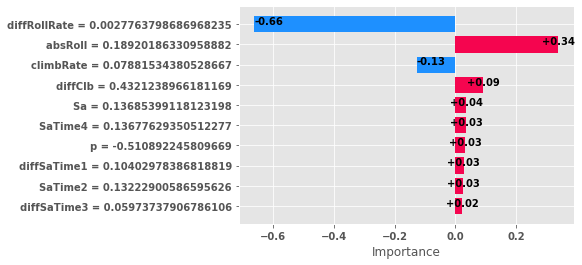

tensor([[0.2689]], grad_fn=<AddBackward0>)

In [12]:
#num of features to use
top_n = 10
ind = np.random.choice(len(test))

kan_model.plot_bars(test[ind][0].reshape(1, len(index_to_name)).to(device), test_data.iloc[0], top_n)
kan_model.predict(test[ind][0].reshape(1, len(index_to_name)).to(device))

# Interpretability Evaluation

In [13]:
'''function to obtain feature scores from KAN model'''

def get_local_values(example, index_to_name):
    array_to_use = np.array(example)    
    array = torch.FloatTensor(array_to_use).reshape(1, len(index_to_name))
    
    # Inspect what's actually returned — run this once to confirm shape
    raw = kan_model.get_local_importance(array.to(device))
    
    local_importance = raw  # no [-1] or [0] indexing

    names = []
    values = []
    for i, v in enumerate(local_importance):
        name = index_to_name[i]
        names.append(name)
        values.append(v)
    return names, values

In [14]:
from data_preprocess import BlackBoxWrapper


num_features = len(index_to_name)


bb = BlackBoxWrapper(kan_model, num_features, device)

def black_box(x, S):
    pred = bb(x, S)
    return pred.cpu().detach().numpy()

In [15]:
from tqdm import tqdm
import shapreg
import pickle
import os.path
from numpy.linalg import norm
from scipy.stats import spearmanr
import copy

all_cos_sim = []
all_spearman_c = []
all_krnl = []

valid_count = 0
subsample_indices = np.random.choice(len(test_dataset), size=300, replace=False)
test_subset = [test_dataset[i] for i in subsample_indices]

for x_, _ in tqdm(test_subset):
    x_ = x_.unsqueeze(0)   # 🔥 IMPORTANT FIX

    _, kan_values = get_local_values(x_, index_to_name)

    x = x_.cpu().numpy()

    try:
        shap_values, all_results = shapreg.shapley.ShapleyRegression(
            shapreg.games.PredictionGame(black_box, x),
            batch_size=256,
            paired_sampling=True,
            detect_convergence=True,
            bar=False,
            return_all=True
        )
        valid_count += 1
    except:
        print('Singularity exception!')
        continue

    kan_values = np.atleast_1d(np.array(kan_values)).reshape(-1)
    knl_shp = shap_values.values.reshape(-1)

    den = norm(kan_values) * norm(knl_shp)
    if den == 0:
        continue

    all_cos_sim.append(np.dot(kan_values, knl_shp) / den)

    coef, _ = spearmanr(kan_values, knl_shp)
    all_spearman_c.append(coef)

print("\n===== FINAL RESULTS =====")
print("Valid samples:", valid_count)

mean_cos_sim = np.mean(all_cos_sim)
mean_spearman_c = np.mean(all_spearman_c)

std_cos_sim = np.std(all_cos_sim)
std_spearman_c = np.std(all_spearman_c)

print(f"Cosine similarity: {mean_cos_sim:.4f} ± {std_cos_sim:.4f}")
print(f"Spearman rank: {mean_spearman_c:.4f} ± {std_spearman_c:.4f}")

with open(f'{data_name}/{data_name}_krnlshp_kan.pickle', 'wb') as file:
    pickle.dump(all_krnl, file)

100%|██████████| 300/300 [00:59<00:00,  5.02it/s]


===== FINAL RESULTS =====
Valid samples: 300
Cosine similarity: 0.9943 ± 0.0066
Spearman rank: 0.9473 ± 0.0363
